<a href="https://colab.research.google.com/github/samer-glitch/Personalized-Ozempic-treatment-A-Systematic-Review-and-AI-Driven-Future-Perspectives/blob/main/Personalized_Ozempic_treatment_A_Systematic_Review_and_AI_Driven_Future_Perspectives.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

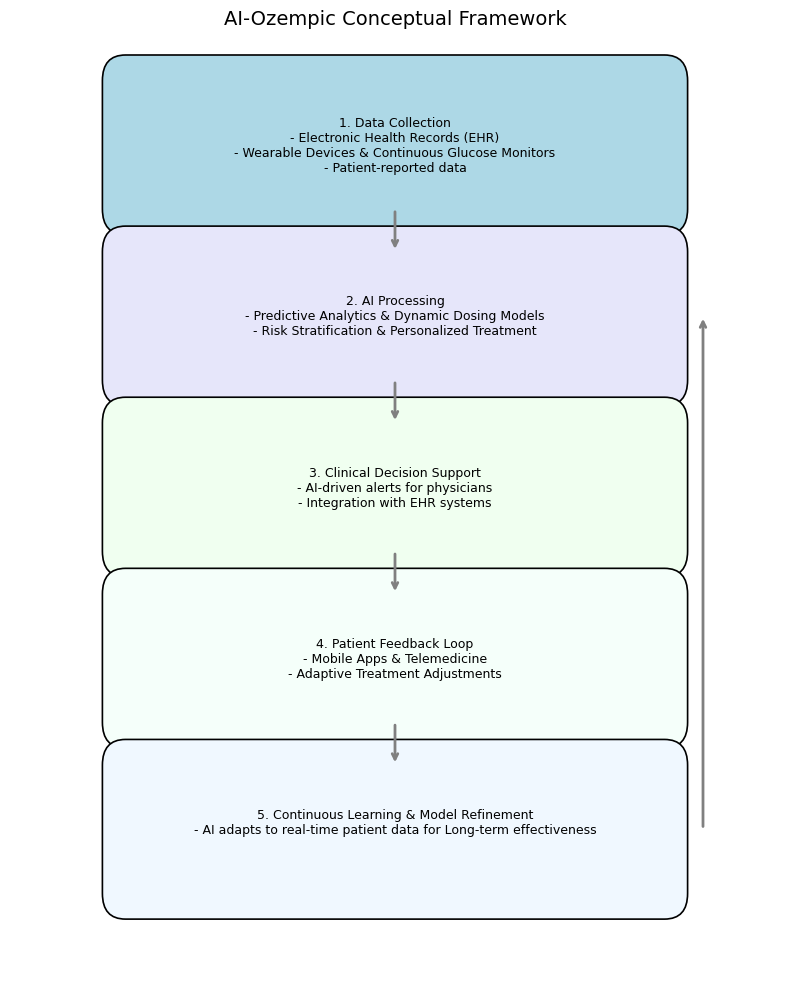

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

def add_box(ax, x, y, width, height, text, facecolor='lightblue'):
    """
    Draws a rounded rectangle (FancyBboxPatch) with centered text.
    (x, y) is the bottom-left corner of the rectangle.
    """
    box = FancyBboxPatch(
        (x, y), width, height,
        boxstyle='round,pad=0.3',
        fc=facecolor, ec='black',
        linewidth=1.2
    )
    ax.add_patch(box)
    # Centered text
    ax.text(
        x + width / 2, y + height / 2, text,
        ha='center', va='center', fontsize=9,
        wrap=True
    )

# -----------------------------------------------------------
# 1) CREATE FIGURE AND AXES
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 10))

# Increase the y-limit top boundary to ensure the top block is fully visible.
ax.set_xlim(0, 10)
ax.set_ylim(-9, 2)  # was ( -9, 1 ) => now more space above (2.3).
ax.axis('off')

# Define block layout
box_width  = 7
box_height = 1.5
x_coord    = 1.5
y_positions = [0, -2, -4, -6, -8]  # from top to bottom

# Step texts
step_texts = [
    "1. Data Collection\n"
    "- Electronic Health Records (EHR)\n"
    "- Wearable Devices & Continuous Glucose Monitors\n"
    "- Patient-reported data",

    "2. AI Processing\n"
    "- Predictive Analytics & Dynamic Dosing Models\n"
    "- Risk Stratification & Personalized Treatment",

    "3. Clinical Decision Support\n"
    "- AI-driven alerts for physicians\n"
    "- Integration with EHR systems",

    "4. Patient Feedback Loop\n"
    "- Mobile Apps & Telemedicine\n"
    "- Adaptive Treatment Adjustments",

    "5. Continuous Learning & Model Refinement\n"
    "- AI adapts to real-time patient data for Long-term effectiveness\n"
]

# Box colors
box_colors = ["lightblue", "lavender", "honeydew", "mintcream", "aliceblue"]

# -----------------------------------------------------------
# 2) DRAW BOXES
# -----------------------------------------------------------
for i in range(5):
    add_box(
        ax,
        x_coord,
        y_positions[i],
        box_width,
        box_height,
        step_texts[i],
        facecolor=box_colors[i % len(box_colors)]
    )

# -----------------------------------------------------------
# 3) DRAW VERTICAL ARROWS (STEP 1→2, 2→3, 3→4, 4→5)
# -----------------------------------------------------------
for i in range(4):
    start_x = x_coord + box_width / 2
    start_y = y_positions[i]
    end_x   = x_coord + box_width / 2
    end_y   = y_positions[i + 1] + box_height

    ax.annotate(
        "",
        xy=(end_x, end_y),
        xytext=(start_x, start_y),
        arrowprops=dict(arrowstyle="->", color="gray", lw=2)
    )

# -----------------------------------------------------------
# 4) STRAIGHT ARROW OUTSIDE BLOCKS FROM STEP 5 BACK TO STEP 2
# -----------------------------------------------------------
# We'll place this arrow on the right side, x ~ box_right + offset
arrow_x = x_coord + box_width + 0.5  # shift arrow 0.5 units to the right
step5_y = y_positions[4] + box_height / 2
step2_y = y_positions[1] + box_height / 2

# Straight arrow going from step5_y (lower) up to step2_y (higher)
ax.annotate(
    "",
    xy=(arrow_x, step2_y),
    xytext=(arrow_x, step5_y),
    arrowprops=dict(arrowstyle="->", color="gray", lw=2)
)

# -----------------------------------------------------------
# 5) FIGURE TITLE
# -----------------------------------------------------------
# Slightly reduce pad so there's small spacing between title and top box.
plt.title("AI-Ozempic Conceptual Framework", fontsize=14, pad=10)

plt.tight_layout()
plt.show()


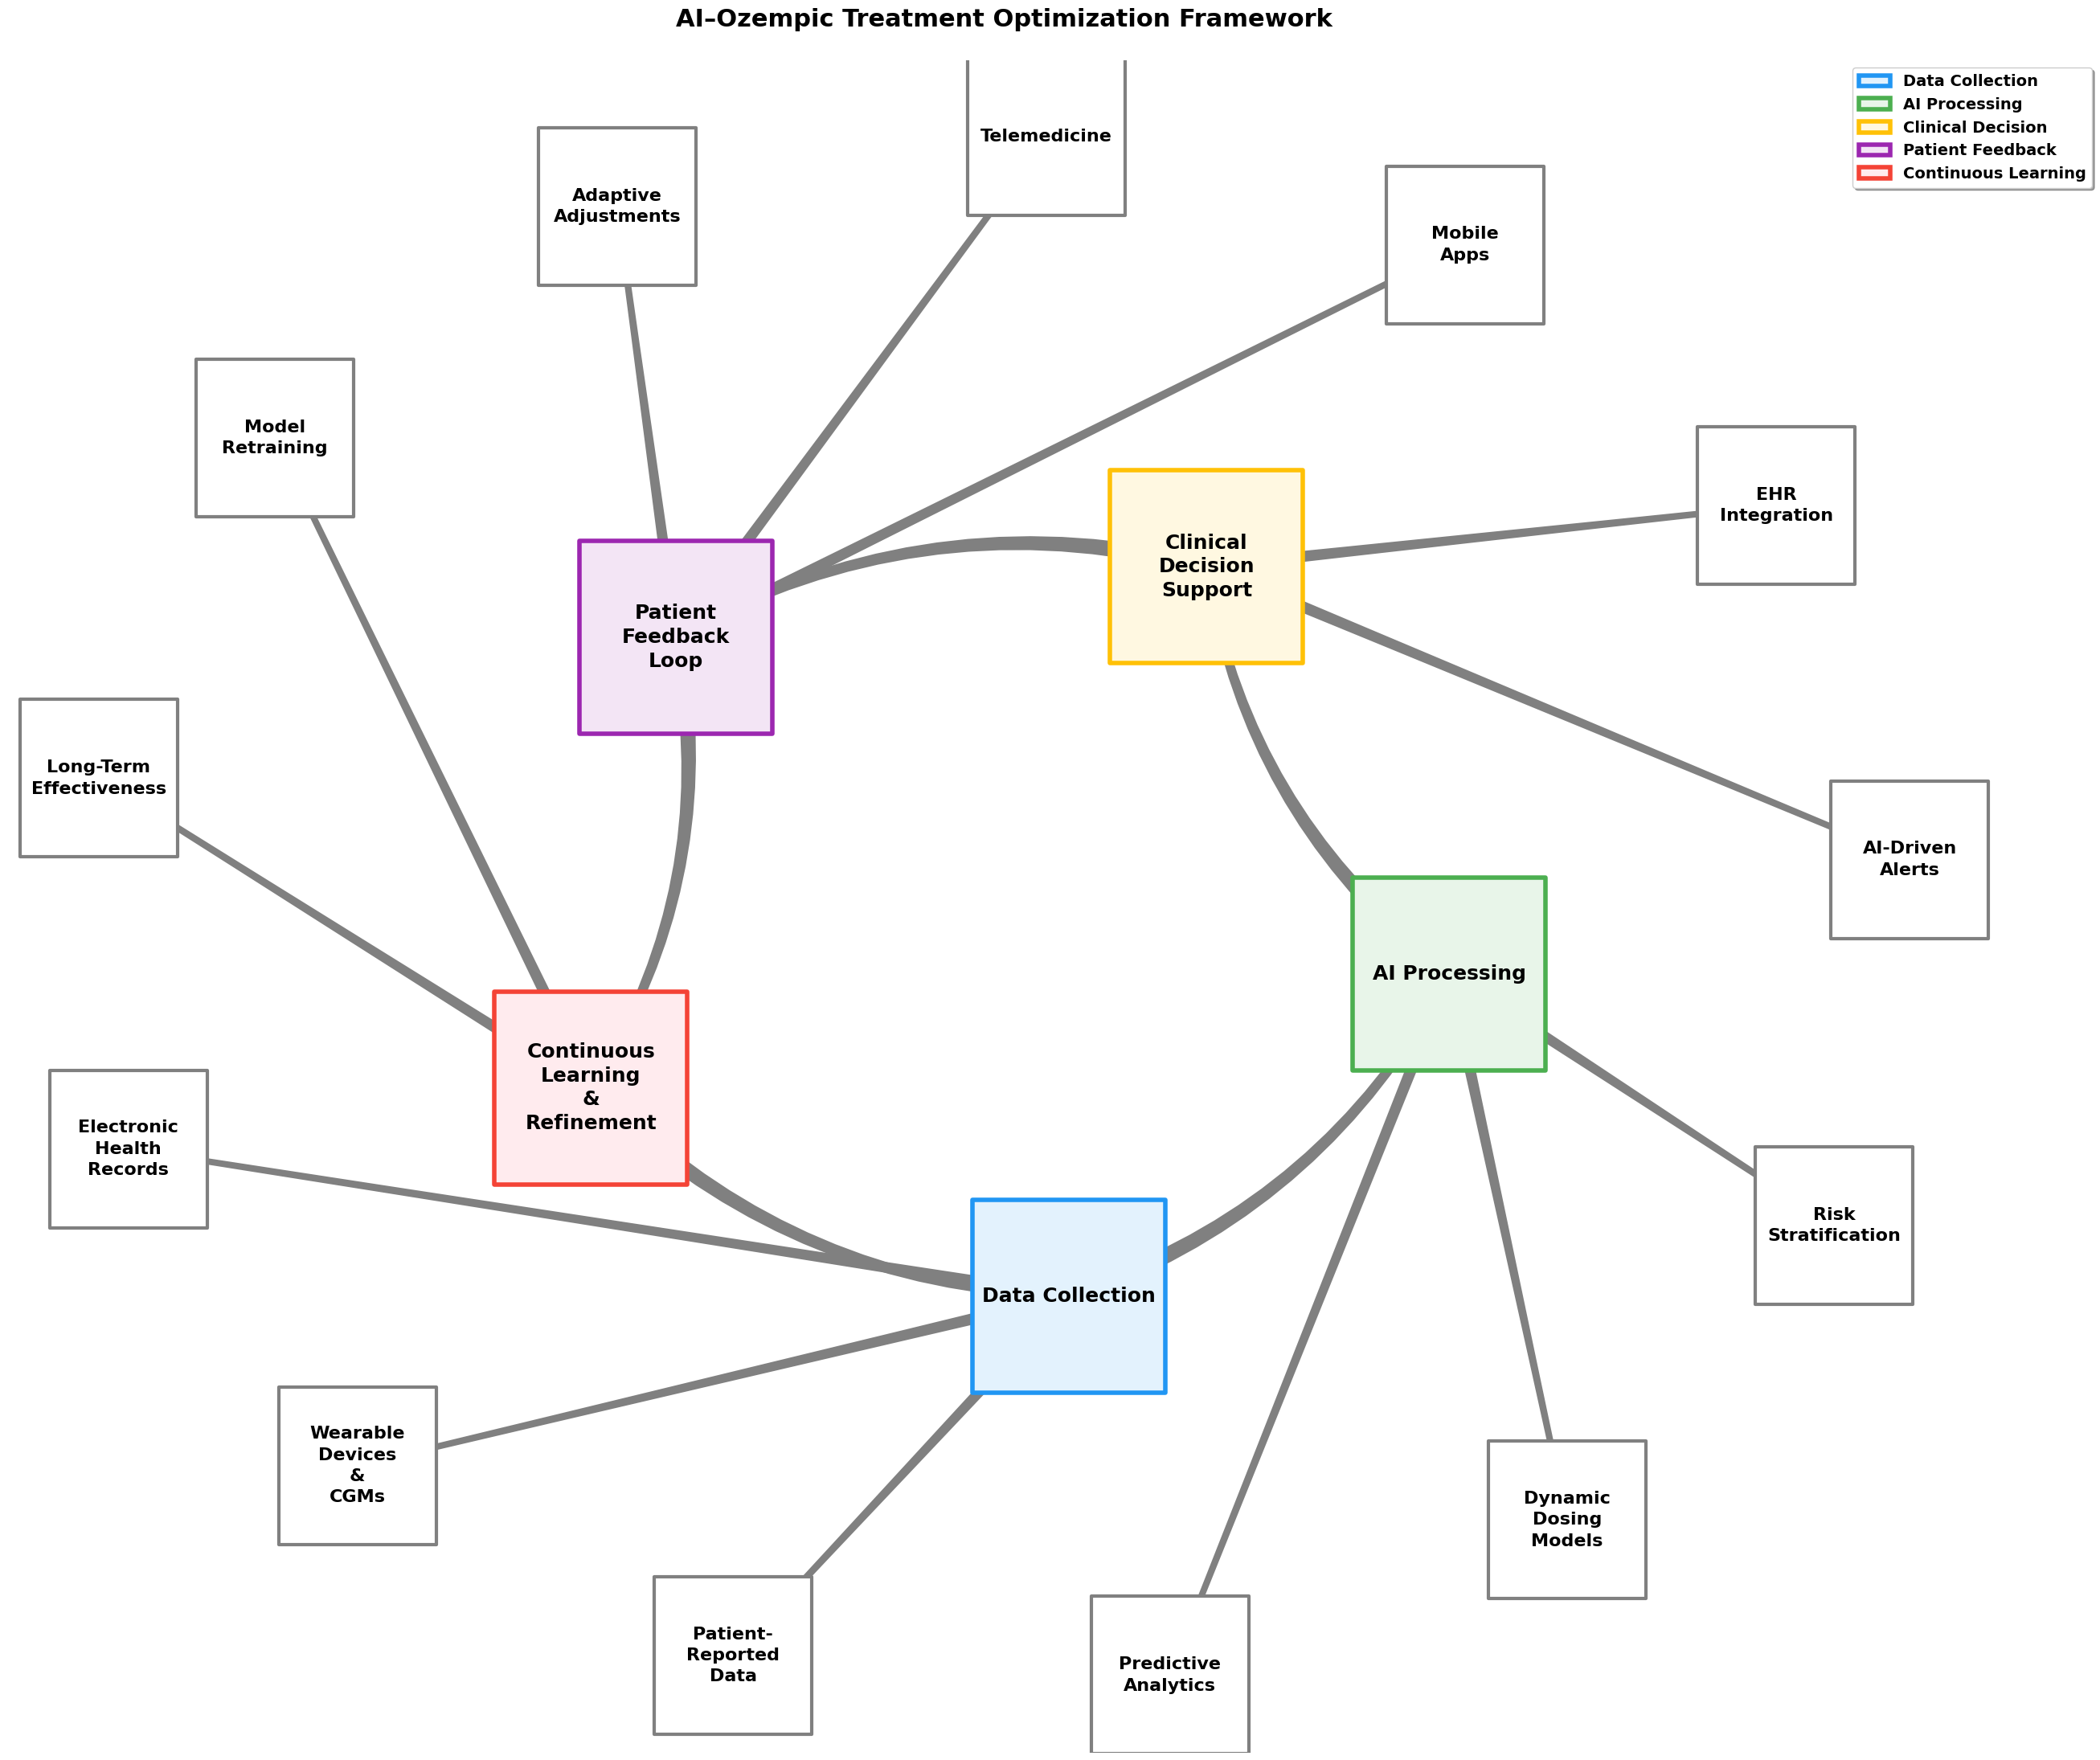

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import FancyArrowPatch

# Use DejaVu Sans for all text
plt.rcParams['font.family'] = 'DejaVu Sans'

# Configure nodes with three-line labels for selected main nodes and increased sizes
main_nodes = [
    ("Data Collection", {"color": "#e3f2fd", "edge": "#2196f3"}),
    ("AI Processing", {"color": "#e8f5e9", "edge": "#4caf50"}),
    ("Clinical\nDecision\nSupport", {"color": "#fff8e1", "edge": "#ffc107"}),
    ("Patient\nFeedback\nLoop", {"color": "#f3e5f5", "edge": "#9c27b0"}),
    ("Continuous\nLearning\n&\nRefinement", {"color": "#ffebee", "edge": "#f44336"})
]

sub_nodes = [
    ("Electronic\nHealth\nRecords", {"parent": "Data Collection"}),
    ("Wearable\nDevices\n&\nCGMs", {"parent": "Data Collection"}),
    ("Patient-\nReported\nData", {"parent": "Data Collection"}),
    ("Predictive\nAnalytics", {"parent": "AI Processing"}),
    ("Dynamic\nDosing\nModels", {"parent": "AI Processing"}),
    ("Risk\nStratification", {"parent": "AI Processing"}),
    ("AI-Driven\nAlerts", {"parent": "Clinical\nDecision\nSupport"}),
    ("EHR\nIntegration", {"parent": "Clinical\nDecision\nSupport"}),
    ("Mobile\nApps", {"parent": "Patient\nFeedback\nLoop"}),
    ("Telemedicine", {"parent": "Patient\nFeedback\nLoop"}),
    ("Adaptive\nAdjustments", {"parent": "Patient\nFeedback\nLoop"}),
    ("Model\nRetraining", {"parent": "Continuous\nLearning\n&\nRefinement"}),
    ("Long-Term\nEffectiveness", {"parent": "Continuous\nLearning\n&\nRefinement"})
]

# Create graph structure
G = nx.DiGraph()
G.add_nodes_from([(node, attrs) for node, attrs in main_nodes])
G.add_nodes_from([(node, {"parent": attrs["parent"]}) for node, attrs in sub_nodes])

# Main flow connections
main_flow = [n[0] for n in main_nodes]
for i in range(len(main_flow) - 1):
    G.add_edge(main_flow[i], main_flow[i + 1])
G.add_edge(main_flow[-1], main_flow[0])  # Feedback loop

# Sub-node connections
for node, attrs in sub_nodes:
    G.add_edge(attrs["parent"], node)

# Layout
pos = nx.shell_layout(
    G,
    nlist=[main_flow, [n[0] for n in sub_nodes]],
    rotate=30,
    scale=6
)

plt.figure(figsize=(26, 22))

# Draw main nodes
for node, attrs in main_nodes:
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=[node],
        node_size=30000,
        node_shape="s",
        node_color=attrs["color"],
        edgecolors=attrs["edge"],
        linewidths=4
    )
    plt.text(
        pos[node][0], pos[node][1], node,
        ha='center', va='center',
        fontsize=18, linespacing=1.3
    )

# Draw sub-nodes
nx.draw_networkx_nodes(
    G, pos,
    nodelist=[n[0] for n in sub_nodes],
    node_size=20000,
    node_shape="s",
    node_color="white",
    edgecolors="gray",
    linewidths=3
)
for node, _ in sub_nodes:
    plt.text(
        pos[node][0], pos[node][1], node,
        ha='center', va='center',
        fontsize=16, linespacing=1.4
    )

# Draw curved cycle arrows
for i in range(len(main_flow)):
    start = main_flow[i]
    end = main_flow[(i + 1) % len(main_flow)]
    rad = 0.2 if i % 2 == 0 else -0.2
    arrow = FancyArrowPatch(
        pos[start], pos[end],
        connectionstyle=f"arc3,rad={rad}",
        arrowstyle="fancy,head_length=1.5,head_width=1",
        linewidth=4, color="gray",
        mutation_scale=30
    )
    plt.gca().add_patch(arrow)

# Draw straight sub-node arrows
for node, attrs in sub_nodes:
    arrow = FancyArrowPatch(
        pos[attrs['parent']], pos[node],
        arrowstyle="fancy,head_length=1.5,head_width=1",
        linewidth=3, color="gray",
        mutation_scale=20
    )
    plt.gca().add_patch(arrow)

# Title in bold
plt.box(False)
plt.title(
    "AI–Ozempic Treatment Optimization Framework",
    fontsize=22, pad=30, fontweight='bold'
)

# Legend
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, fc="#e3f2fd", ec="#2196f3", lw=4, label="Data Collection"),
    plt.Rectangle((0, 0), 1, 1, fc="#e8f5e9", ec="#4caf50", lw=4, label="AI Processing"),
    plt.Rectangle((0, 0), 1, 1, fc="#fff8e1", ec="#ffc107", lw=4, label="Clinical Decision"),
    plt.Rectangle((0, 0), 1, 1, fc="#f3e5f5", ec="#9c27b0", lw=4, label="Patient Feedback"),
    plt.Rectangle((0, 0), 1, 1, fc="#ffebee", ec="#f44336", lw=4, label="Continuous Learning")
]
plt.legend(
    handles=legend_elements,
    loc="upper right",
    bbox_to_anchor=(1.05, 1),
    fontsize=14,
    title_fontsize=16,
    frameon=True,
    shadow=True
)

plt.tight_layout()
plt.show()


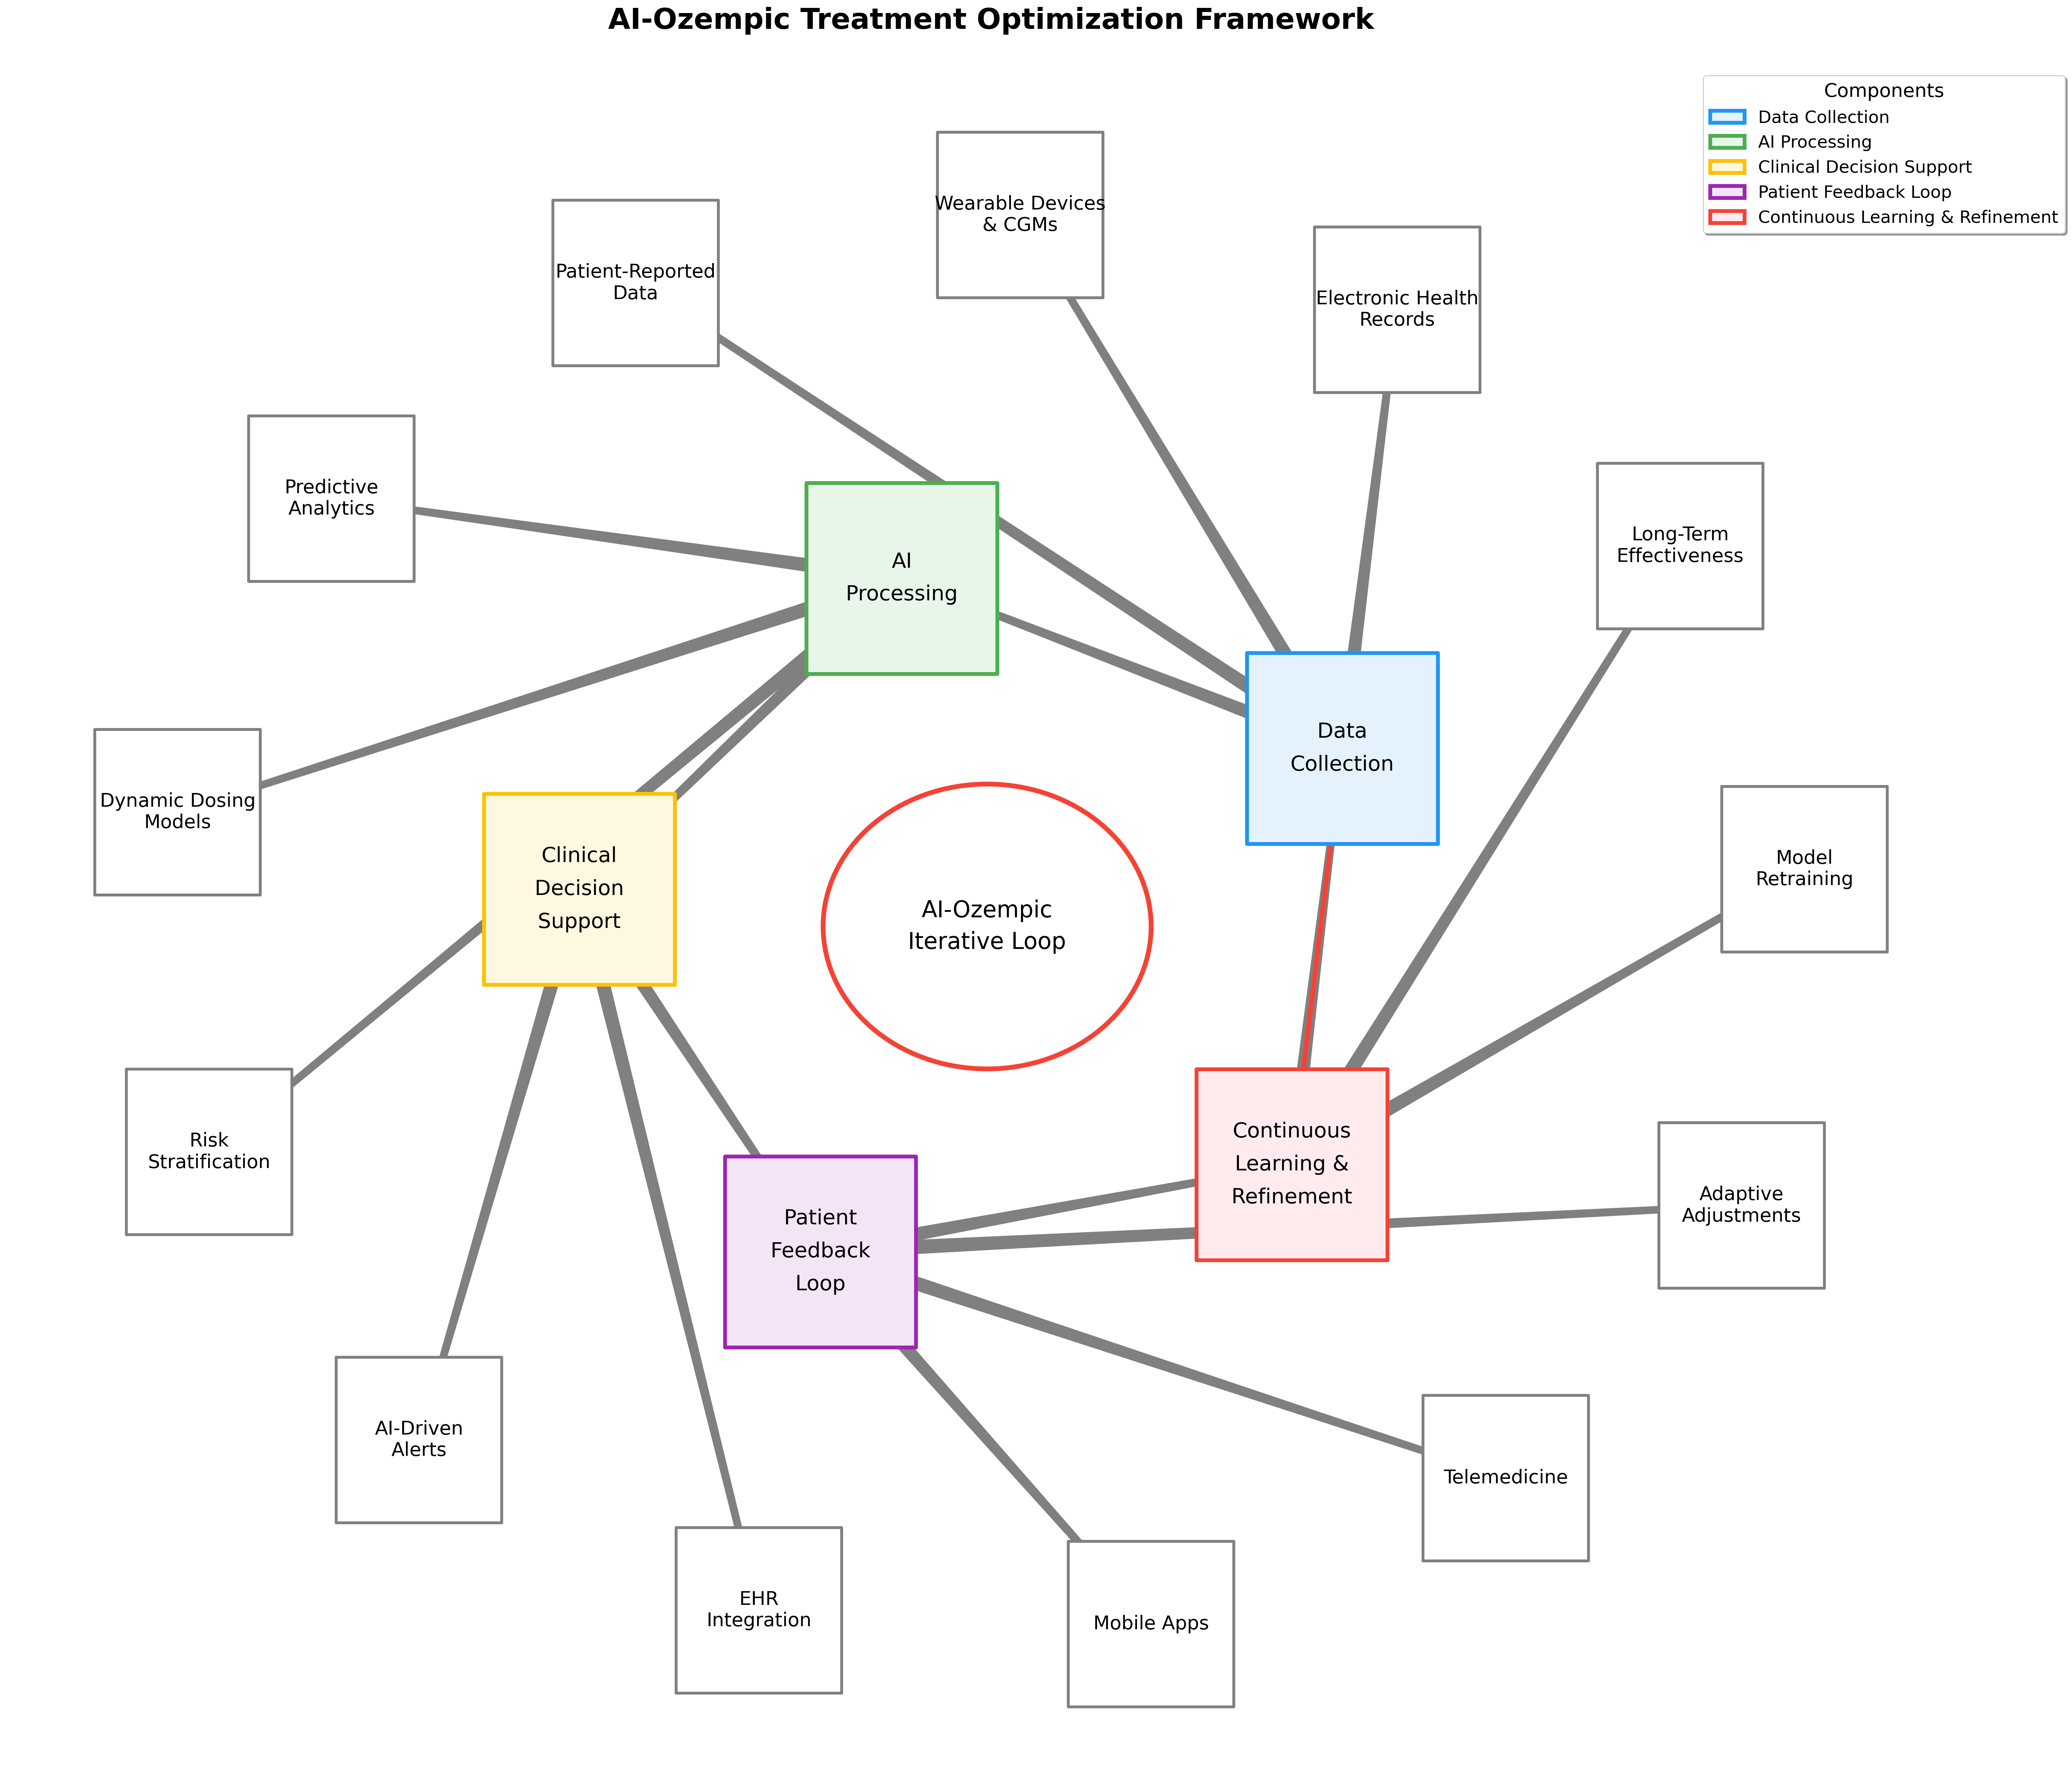

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from matplotlib.patches import Circle

# ── Font Settings ──────────────────────────────────────────────────────
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.weight'] = 'normal'  # Default to regular weight

# ── 1. MAIN NODES ────────────────────────────────────────────────────
main_nodes = [
    ("Data Collection",                    {"color": "#e3f2fd", "edge": "#2196f3"}),
    ("AI Processing",                      {"color": "#e8f5e9", "edge": "#4caf50"}),
    ("Clinical Decision Support",          {"color": "#fff8e1", "edge": "#ffc107"}),
    ("Patient Feedback Loop",              {"color": "#f3e5f5", "edge": "#9c27b0"}),
    ("Continuous Learning & Refinement",   {"color": "#ffebee", "edge": "#f44336"})
]

display_labels = {
    "Data Collection":              "Data\nCollection",
    "AI Processing":                "AI\nProcessing",
    "Clinical Decision Support":    "Clinical\nDecision\nSupport",
    "Patient Feedback Loop":        "Patient\nFeedback\nLoop",
    "Continuous Learning & Refinement": "Continuous\nLearning &\nRefinement"
}

# ── 2. SUB‑NODES (LARGER BOXES) ──────────────────────────────────────
sub_nodes = [
    ("Electronic Health\nRecords",           {"parent": "Data Collection"}),
    ("Wearable Devices\n& CGMs",             {"parent": "Data Collection"}),
    ("Patient-Reported\nData",               {"parent": "Data Collection"}),
    ("Predictive\nAnalytics",                {"parent": "AI Processing"}),
    ("Dynamic Dosing\nModels",               {"parent": "AI Processing"}),
    ("Risk\nStratification",                 {"parent": "AI Processing"}),
    ("AI-Driven\nAlerts",                    {"parent": "Clinical Decision Support"}),
    ("EHR\nIntegration",                     {"parent": "Clinical Decision Support"}),
    ("Mobile Apps",                          {"parent": "Patient Feedback Loop"}),
    ("Telemedicine",                         {"parent": "Patient Feedback Loop"}),
    ("Adaptive\nAdjustments",                {"parent": "Patient Feedback Loop"}),
    ("Model\nRetraining",                    {"parent": "Continuous Learning & Refinement"}),
    ("Long-Term\nEffectiveness",             {"parent": "Continuous Learning & Refinement"})
]

# ── 3. BUILD GRAPH ────────────────────────────────────────────────────
G = nx.DiGraph()
G.add_nodes_from([(node, attrs) for node, attrs in main_nodes])
G.add_nodes_from([(node, {"parent": attrs["parent"]}) for node, attrs in sub_nodes])

# Main-cycle edges
main_flow = [n for n, _ in main_nodes]
for u, v in zip(main_flow, main_flow[1:] + main_flow[:1]):
    G.add_edge(u, v)

# Sub-node spokes
for node, attrs in sub_nodes:
    G.add_edge(attrs["parent"], node)

# ── 4. LAYOUT ─────────────────────────────────────────────────────────
pos = nx.shell_layout(
    G,
    nlist=[main_flow, [n for n, _ in sub_nodes]],
    rotate=np.deg2rad(30),
    scale=5
)

# ── 5. PLOT ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(30, 26), dpi=200)

# Draw main nodes (regular weight)
for node, attrs in main_nodes:
    nx.draw_networkx_nodes(
        G, pos, nodelist=[node],
        node_size=40000, node_shape="s",
        node_color=attrs["color"], edgecolors=attrs["edge"], linewidths=4,
        ax=ax
    )
    plt.text(
        pos[node][0], pos[node][1], display_labels[node],
        ha='center', va='center',
        fontsize=22, fontweight='normal',  # Explicit regular weight
        linespacing=1.8
    )

# Draw LARGER sub-nodes (size increased to 30000)
sub_labels = [n for n, _ in sub_nodes]
nx.draw_networkx_nodes(
    G, pos, nodelist=sub_labels,
    node_size=30000, node_shape="s",  # Larger boxes
    node_color="white", edgecolors="gray", linewidths=3,
    ax=ax
)
for node in sub_labels:
    plt.text(
        pos[node][0], pos[node][1], node,
        ha='center', va='center',
        fontsize=20, fontweight='normal',  # Regular weight
        linespacing=1.2
    )

# Draw edges
nx.draw_networkx_edges(
    G, pos, arrowstyle="fancy,head_length=1.5,head_width=1",
    arrowsize=30, width=4, edge_color="gray",
    ax=ax
)
nx.draw_networkx_edges(
    G, pos, edgelist=[(main_flow[-1], main_flow[0])],
    edge_color="#f44336", width=5, arrowsize=35,
    ax=ax
)

# ── SMALLER CENTER CIRCLE (NO ARROW) ──────────────────────────────────
center_circle = Circle((0, 0), 1.0, fill=True, color='white', ec='#f44336', lw=5)
ax.add_patch(center_circle)

# Center text (regular weight)
plt.text(0, 0, "AI-Ozempic\nIterative Loop",
         ha='center', va='center',
         fontsize=24, fontweight='normal',  # Regular weight
         linespacing=1.5)

# ── Title (ONLY BOLD ELEMENT) ─────────────────────────────────────────
plt.title(
    "AI-Ozempic Treatment Optimization Framework",
    fontsize=30, pad=40, fontweight='bold'  # Only bold text
)

# Legend (regular weight)
legend_elements = [
    plt.Rectangle((0,0),1,1,fc=attrs["color"],ec=attrs["edge"],lw=4,label=node)
    for node, attrs in main_nodes
]
plt.legend(
    handles=legend_elements, loc="upper right",
    bbox_to_anchor=(1.05, 1), fontsize=18,
    title="Components", title_fontsize=20,
    frameon=True, shadow=True
)

plt.axis('off')
plt.tight_layout()
plt.savefig("AI-Ozempic_Framework_Final.png", dpi=600, bbox_inches="tight")
plt.show()

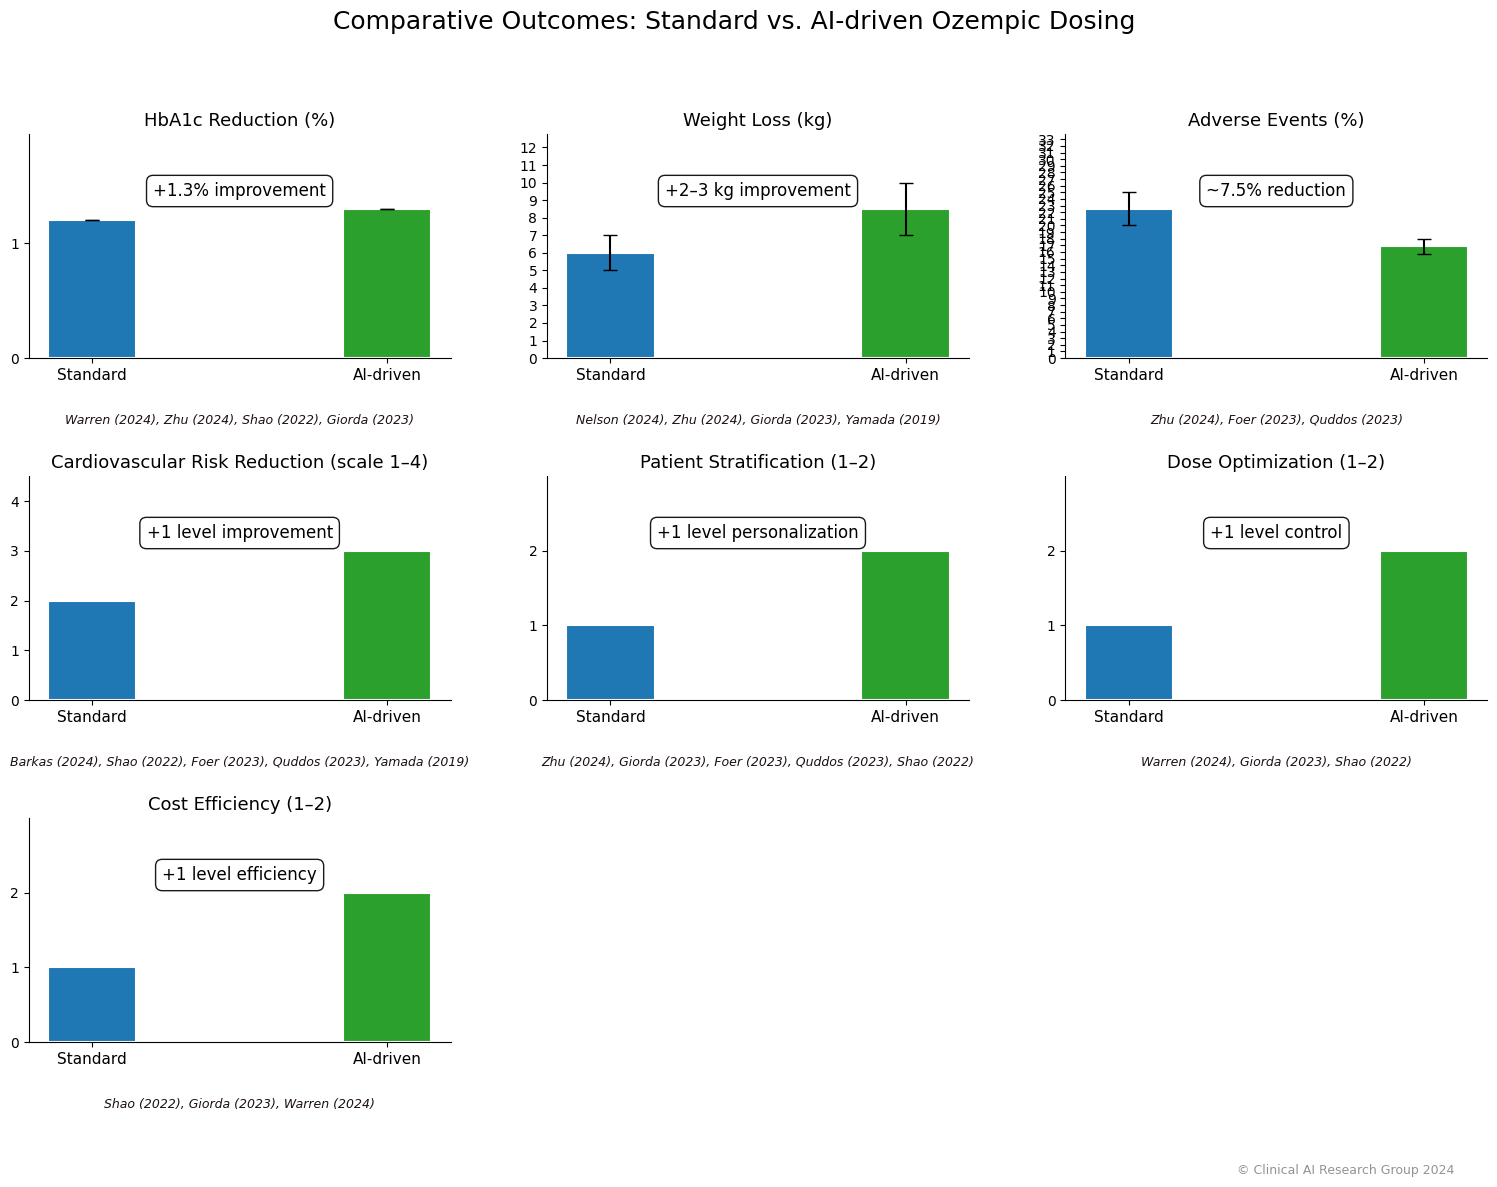

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Updated metrics data with consistent improvement texts
metrics = {
    "HbA1c Reduction (%)": {
        "Standard": 1.2,
        "AI": 1.3,
        "range_std": [1.2, 1.2],
        "range_ai": [1.3, 1.3],
        "Improvement": "+1.3% improvement",
        "Evidence": "Warren (2024), Zhu (2024), Shao (2022), Giorda (2023)"
    },
    "Weight Loss (kg)": {
        "Standard": 6.0,
        "AI": 8.5,
        "range_std": [5.0, 7.0],
        "range_ai": [7.0, 10.0],
        "Improvement": "+2–3 kg improvement",
        "Evidence": "Nelson (2024), Zhu (2024), Giorda (2023), Yamada (2019)"
    },
    "Adverse Events (%)": {
        "Standard": 22.5,
        "AI": 16.9,
        "range_std": [20, 25],
        "range_ai": [15.75, 18.0],
        "Improvement": "~7.5% reduction",
        "Evidence": "Zhu (2024), Foer (2023), Quddos (2023)"
    },
    "Cardiovascular Risk Reduction (scale 1–4)": {
        "Standard": 2,
        "AI": 3,
        "Improvement": "+1 level improvement",
        "Evidence": "Barkas (2024), Shao (2022), Foer (2023), Quddos (2023), Yamada (2019)"
    },
    "Patient Stratification (1–2)": {
        "Standard": 1,
        "AI": 2,
        "Improvement": "+1 level personalization",
        "Evidence": "Zhu (2024), Giorda (2023), Foer (2023), Quddos (2023), Shao (2022)"
    },
    "Dose Optimization (1–2)": {
        "Standard": 1,
        "AI": 2,
        "Improvement": "+1 level control",
        "Evidence": "Warren (2024), Giorda (2023), Shao (2022)"
    },
    "Cost Efficiency (1–2)": {
        "Standard": 1,
        "AI": 2,
        "Improvement": "+1 level efficiency",
        "Evidence": "Shao (2022), Giorda (2023), Warren (2024)"
    }
}

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))
axes = axes.flatten()

standard_color = '#1f77b4'
ai_color = '#2ca02c'

for idx, (metric, data) in enumerate(metrics.items()):
    ax = axes[idx]
    ax.bar(["Standard", "AI-driven"],
           [data["Standard"], data["AI"]],
           color=[standard_color, ai_color],
           width=0.3, edgecolor='white', linewidth=1.5)

    if "range_std" in data and "range_ai" in data:
        std_val = data["Standard"]
        ai_val = data["AI"]
        std_err_down = std_val - data["range_std"][0]
        std_err_up = data["range_std"][1] - std_val
        ai_err_down = ai_val - data["range_ai"][0]
        ai_err_up = data["range_ai"][1] - ai_val
        ax.errorbar(0, std_val, yerr=[[std_err_down], [std_err_up]], fmt='none', color='black', capsize=5)
        ax.errorbar(1, ai_val, yerr=[[ai_err_down], [ai_err_up]], fmt='none', color='black', capsize=5)

    # Elevated improvement text with consistent styling
    max_val = max(data["Standard"], data["AI"])
    ax.text(0.5, max_val * 1.12, data["Improvement"],
            ha='center', va='center', fontsize=12, fontweight='medium',
            bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='black', lw=1, alpha=0.9))

    ax.text(0.5, -0.25, data["Evidence"],
            ha='center', va='top', transform=ax.transAxes,
            fontsize=9, style='italic', color='#1c1010')

    ax.set_ylim(0, max_val * 1.5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Standard', 'AI-driven'], fontsize=11)
    ax.set_yticks(np.arange(0, max_val * 1.5, step=1))
    ax.set_title(metric, fontsize=13)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

for j in range(len(metrics), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Comparative Outcomes: Standard vs. AI-driven Ozempic Dosing", fontsize=18)
fig.text(0.95, 0.01, "© Clinical AI Research Group 2024", ha='right', fontsize=9, color='#666666', alpha=0.7)
plt.tight_layout(rect=[0.02, 0.04, 0.98, 0.94])
plt.show()


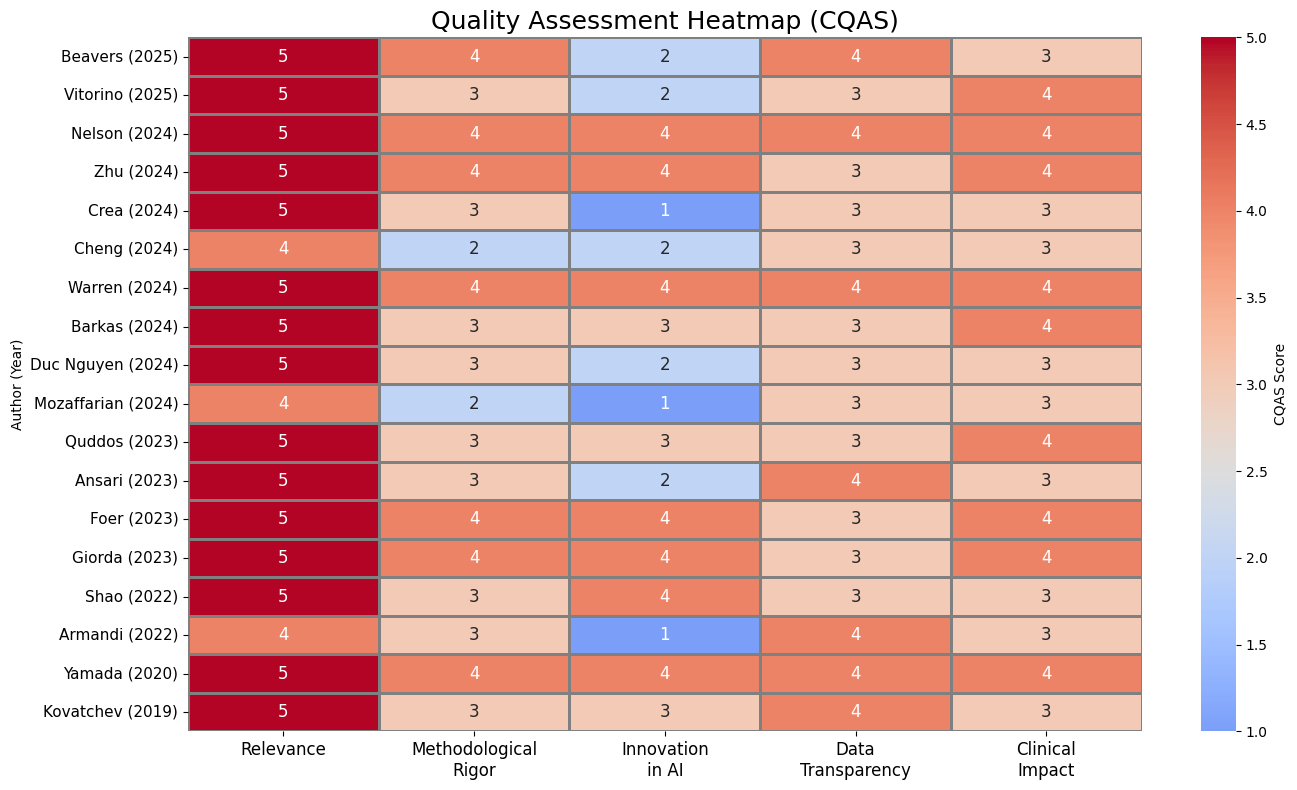

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data for the Quality Assessment Scores (18 studies)
data = {
    'Author (Year)': [
        'Beavers (2025)', 'Vitorino (2025)', 'Nelson (2024)', 'Zhu (2024)', 'Crea (2024)',
        'Cheng (2024)', 'Warren (2024)', 'Barkas (2024)', 'Duc Nguyen (2024)', 'Mozaffarian (2024)',
        'Quddos (2023)', 'Ansari (2023)', 'Foer (2023)', 'Giorda (2023)', 'Shao (2022)',
        'Armandi (2022)', 'Yamada (2020)', 'Kovatchev (2019)'
    ],
    'Relevance': [
        5, 5, 5, 5, 5, 4, 5, 5, 5, 4, 5, 5, 5, 5, 5, 4, 5, 5
    ],
    'Methodological\nRigor': [
        4, 3, 4, 4, 3, 2, 4, 3, 3, 2, 3, 3, 4, 4, 3, 3, 4, 3
    ],
    'Innovation\nin AI': [
        2, 2, 4, 4, 1, 2, 4, 3, 2, 1, 3, 2, 4, 4, 4, 1, 4, 3
    ],
    'Data\nTransparency': [
        4, 3, 4, 3, 3, 3, 4, 3, 3, 3, 3, 4, 3, 3, 3, 4, 4, 4
    ],
    'Clinical\nImpact': [
        3, 4, 4, 4, 3, 3, 4, 4, 3, 3, 4, 3, 4, 4, 3, 3, 4, 3
    ]
}

# Creating the DataFrame
df = pd.DataFrame(data)
df.set_index('Author (Year)', inplace=True)

# Create the heatmap using Seaborn with increased font sizes
plt.figure(figsize=(14, 8))
sns.heatmap(df, annot=True, cmap='coolwarm', cbar_kws={'label': 'CQAS Score'},
            linewidths=1, linecolor='gray', fmt='g', center=2.5,
            annot_kws={"size": 12},
            xticklabels=True, yticklabels=True)

# Add title
plt.title("Quality Assessment Heatmap (CQAS)", fontsize=18)

# Rotate x-axis labels and increase font size
plt.xticks(rotation=0, ha='center', fontsize=12)
plt.yticks(fontsize=11)

# Show the plot
plt.tight_layout()
plt.show()


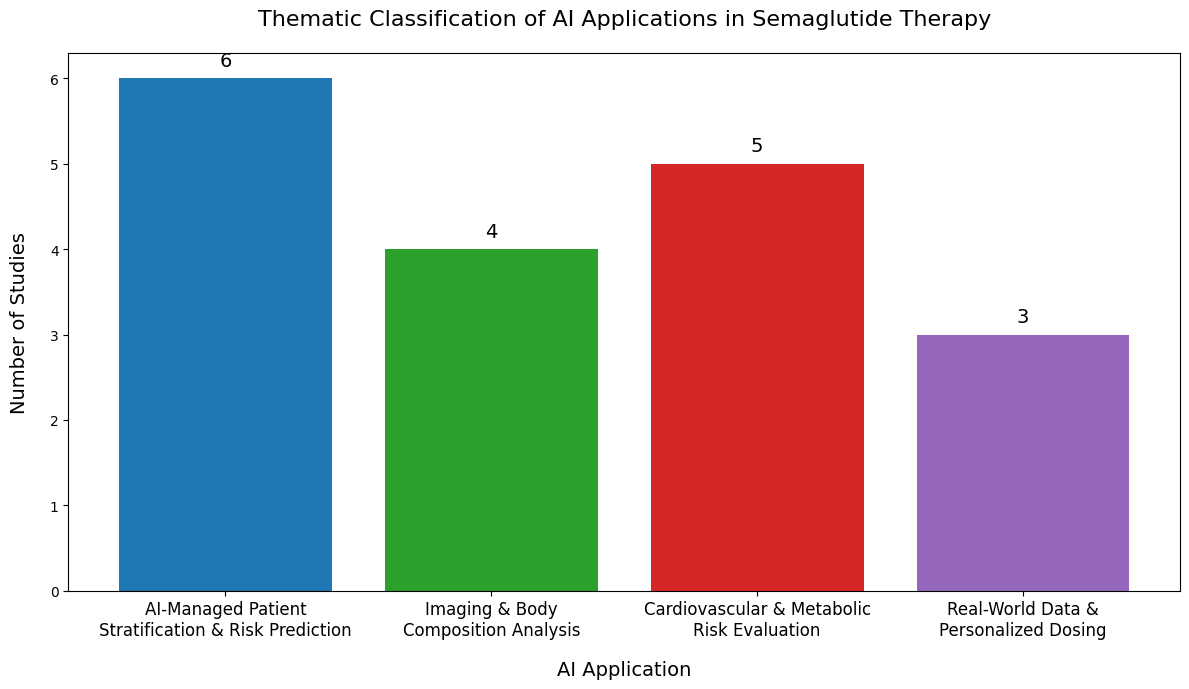

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data for AI Applications in Studies
ai_categories = {
    "AI-Managed Patient\nStratification & Risk Prediction": 6,
    "Imaging & Body\nComposition Analysis": 4,
    "Cardiovascular & Metabolic\nRisk Evaluation": 5,
    "Real-World Data &\nPersonalized Dosing": 3
}

# Set up the figure with larger size for better readability
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the data with distinct colors
colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd']  # Blue, Green, Red, Purple
bars = ax.bar(ai_categories.keys(), ai_categories.values(), color=colors)

# Enhance the plot
ax.set_title('Thematic Classification of AI Applications in Semaglutide Therapy', fontsize=16, pad=20)
ax.set_xlabel('AI Application', fontsize=14, labelpad=15)
ax.set_ylabel('Number of Studies', fontsize=14, labelpad=15)

# Remove grid lines
ax.grid(False)

# Adjust the position of the labels with larger font size
ax.set_xticks(np.arange(len(ai_categories)))
ax.set_xticklabels(ai_categories.keys(), fontsize=12, ha='center')

# Add value annotations to bars for a more informative look
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval + 0.1, str(yval), ha='center', va='bottom', fontsize=14)

# Show the plot with tight layout for neat presentation
plt.tight_layout()
plt.show()
